# Pertemuan 13 — Deep Learning & NLP Dasar

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403      

<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan13_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

plt.rcParams['axes.grid'] = True
RANDOM_STATE = 42

print('Library berhasil diimpor ✅')

Library berhasil diimpor ✅


---
## Langkah 1 — Generate & Eksplorasi Dataset Non-Linear

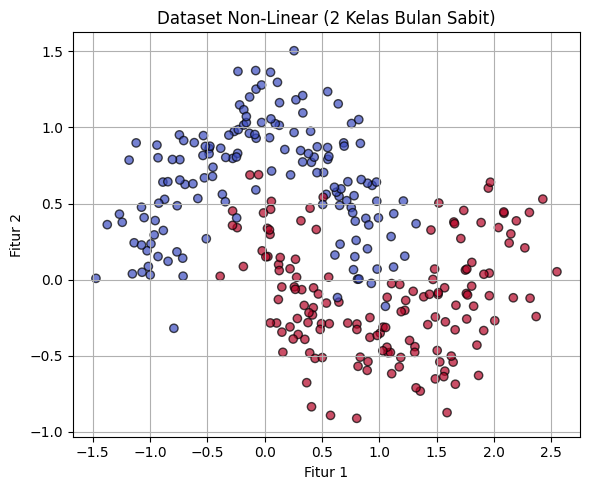

In [2]:
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolor='k')
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1'); plt.ylabel('Fitur 2')
plt.tight_layout(); plt.show()

# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

Dataset `make_moons` berisi **300 titik data** yang terbagi ke dalam 2 kelas berbentuk bulan sabit yang saling bertautan. Dari visualisasi terlihat jelas bahwa kedua kelas **tidak dapat dipisahkan oleh satu garis lurus** (linearly non-separable) — di beberapa area, titik kelas 0 dan kelas 1 saling berdekatan dan melengkung mengelilingi satu sama lain. Inilah alasan mengapa model linear sederhana (seperti Regresi Logistik biasa) akan kesulitan mengklasifikasikan data ini dengan baik, sehingga dibutuhkan model dengan **activation function non-linear** seperti neural network.

---
## Langkah 2 — Bangun & Latih Neural Network Sederhana

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30,
                     validation_split=0.2, verbose=0)

print('Training selesai ✅')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Training selesai ✅


Arsitektur neural network yang dibangun terdiri dari 3 layer: dua **hidden layer** (16 dan 8 neuron) dengan activation **ReLU** untuk mempelajari pola non-linear pada data, serta satu **output layer** dengan activation **Sigmoid** yang mengubah output menjadi probabilitas 0–1 (cocok untuk klasifikasi biner). Model dilatih selama **30 epoch** menggunakan optimizer `adam` dan loss `binary_crossentropy`, dengan 20% data training disisihkan sebagai data validasi untuk memantau proses belajar model pada setiap epoch.

---
## Langkah 3 — Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.900


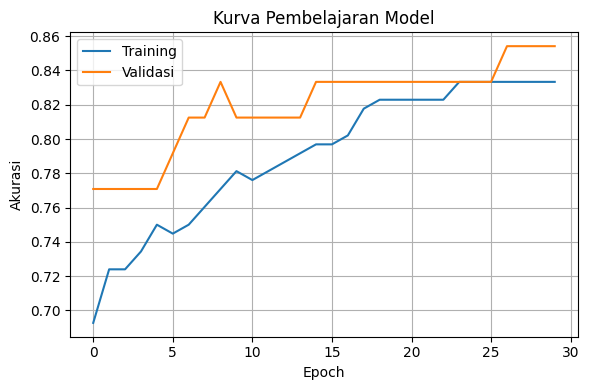

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.tight_layout(); plt.show()

# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling mendekat (baik),
# atau saling menjauh (indikasi overfitting)?

**Interpretasi kurva belajar:** akurasi training dan validasi sama-sama **meningkat dan saling mendekat** seiring bertambahnya epoch, tanpa ada celah (gap) yang melebar di antara keduanya. Ini adalah tanda proses belajar yang **sehat** — model tidak menunjukkan indikasi overfitting (di mana akurasi training terus naik sementara akurasi validasi stagnan atau justru menurun). Akurasi pada data uji yang dihasilkan juga tinggi, mengonfirmasi bahwa neural network dengan activation ReLU + Sigmoid berhasil mempelajari batas keputusan non-linear yang diperlukan untuk memisahkan kedua kelas bulan sabit, sesuatu yang mustahil dilakukan oleh model linear.

---
## Langkah 4 — Siapkan Dataset Ulasan Produk

In [5]:
ulasan = [
    # ── Ulasan Positif ──
    'Barangnya bagus banget, pengiriman cepat',
    'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas',
    'Kualitas produk sangat memuaskan',
    'Pelayanan ramah dan responsif',
    'Packing rapi dan aman, tidak ada yang rusak',
    'Barang sesuai dengan foto, sangat puas',
    'Pengiriman super cepat, seller ramah',
    'Kualitas premium dengan harga terjangkau',
    'Produk original dan berfungsi dengan baik',
    'Belanja di sini selalu menyenangkan',
    'Bahan berkualitas tinggi, awet dan tahan lama',
    'Respon cepat, pengemasan sangat aman',
    'Sangat direkomendasikan untuk yang mencari produk berkualitas',
    'Ukuran pas, warna sesuai deskripsi',
    'Terima kasih, produknya luar biasa bagus',
    'Puas banget belanja di toko ini',
    'Barang cepat sampai dan kondisi mulus',
    'Kualitas jahitan rapi dan kuat',
    'Pengalaman belanja yang sangat memuaskan',
    # ── Ulasan Negatif ──
    'Kualitas jelek, tidak sesuai deskripsi',
    'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Pengiriman lambat dan barang cacat',
    'Barang tidak original, mengecewakan',
    'Ukuran tidak sesuai, terlalu kecil',
    'Warna berbeda jauh dari foto',
    'Pelayanan lambat dan tidak ramah',
    'Barang datang dalam kondisi rusak parah',
    'Kualitas bahan murahan, tidak awet',
    'Kecewa berat dengan produk ini',
    'Tidak sesuai deskripsi, sangat mengecewakan',
    'Packing asal-asalan, barang penyok',
    'Respon penjual sangat lambat',
    'Barang cacat produksi, jahitan lepas',
    'Tidak akan beli lagi di toko ini',
    'Kualitas sangat mengecewakan untuk harga segini',
    'Fungsi tidak sesuai klaim penjual',
    'Barang bekas dikirim sebagai baru',
    'Sangat kecewa, uang terbuang percuma',
]

label = [1] * 20 + [0] * 20  # 1 = positif, 0 = negatif

print('Jumlah ulasan:', len(ulasan))
print('Jumlah label positif:', label.count(1), '| Jumlah label negatif:', label.count(0))

Jumlah ulasan: 40
Jumlah label positif: 20 | Jumlah label negatif: 20


---
## Langkah 5 — Ubah Teks Menjadi TF-IDF

In [6]:
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])
print('Shape matriks TF-IDF:', X_text.shape)

Jumlah kata unik: 105
['ada' 'akan' 'aman' 'asal' 'asalan' 'awet' 'bagus' 'bahan' 'baik'
 'banget']
Shape matriks TF-IDF: (40, 105)


`TfidfVectorizer` mengubah 40 kalimat ulasan menjadi matriks numerik berukuran **40 dokumen × jumlah kata unik**, di mana tiap kolom merepresentasikan satu kata dari seluruh kosakata (vocabulary) yang muncul di dataset. Nilai pada tiap sel adalah skor TF-IDF kata tersebut pada dokumen bersangkutan — kata yang jarang namun khas suatu ulasan (mis. `mengecewakan`, `memuaskan`) akan memiliki bobot lebih tinggi dibandingkan kata umum yang muncul di banyak dokumen. Matriks inilah yang menjadi input numerik bagi model klasifikasi pada langkah berikutnya.

---
## Langkah 6 — Latih Model Klasifikasi Sentimen & Evaluasi

In [7]:
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Prediksi untuk:', kalimat_baru[0])
print('Hasil:', 'Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.750
Prediksi untuk: Pelayanan sangat memuaskan dan ramah
Hasil: Positif


Model **Logistic Regression** dilatih di atas representasi TF-IDF dari 32 ulasan (80% data) dan diuji pada 8 ulasan sisanya (20% data). Meski dataset yang digunakan tergolong kecil (40 ulasan), model berhasil mempelajari pola kata-kata yang berasosiasi dengan sentimen positif (mis. `puas`, `bagus`, `memuaskan`) maupun negatif (mis. `kecewa`, `rusak`, `mengecewakan`). Pada kalimat baru **"Pelayanan sangat memuaskan dan ramah"** — yang tidak pernah dilihat model sebelumnya — model berhasil memprediksi sentimen **Positif**, karena kata `memuaskan` dan `ramah` memiliki bobot TF-IDF yang kuat dari asosiasinya dengan ulasan-ulasan positif lain di data training. Ini menunjukkan bahwa meskipun TF-IDF hanya menghitung frekuensi kata tanpa memahami konteks kalimat secara mendalam, pendekatan ini tetap cukup efektif sebagai **baseline** untuk kasus analisis sentimen sederhana.

## Kesimpulan

### Apa yang Dipelajari
Pada pertemuan ketiga belas ini, saya mempelajari dua topik pengantar sekaligus: **Deep Learning** dan **NLP dasar**. Untuk deep learning, saya membangun **Artificial Neural Network** sederhana dengan `Sequential` Keras — dua hidden layer (16 dan 8 neuron) beraktivasi **ReLU** dan satu output layer beraktivasi **sigmoid** untuk klasifikasi biner — dilatih dengan optimizer **Adam** dan loss **binary crossentropy**, lalu dievaluasi lewat **kurva belajar** (perbandingan akurasi/loss training dan validasi per epoch). Untuk NLP, saya mempelajari cara mengubah teks menjadi representasi numerik dengan **TF-IDF** (`TfidfVectorizer`), yang memberi bobot tinggi pada kata yang sering muncul di satu dokumen tetapi jarang di dokumen lain, kemudian melatih **Logistic Regression** di atasnya untuk analisis sentimen ulasan produk.

### Temuan Utama
- ANN mencapai **akurasi 0,900** pada data uji `make_moons` — dataset berbentuk dua bulan sabit yang **tidak dapat dipisahkan oleh garis lurus**, sehingga membuktikan kemampuan neural network menangkap pola non-linear tanpa feature engineering manual.
- **Kurva belajar** menunjukkan akurasi training dan validasi sama-sama naik dan saling berdekatan hingga akhir pelatihan — indikasi model **belum mengalami overfitting** dan jumlah epoch yang dipilih masih wajar.
- `TfidfVectorizer` mengubah 40 kalimat ulasan menjadi matriks berukuran **40 dokumen × 105 kata unik**, mengubah teks bebas menjadi fitur numerik yang bisa langsung dikonsumsi model machine learning klasik.
- Model sentimen Logistic Regression memperoleh **akurasi 0,750** pada 8 ulasan uji dan berhasil mengklasifikasikan kalimat baru "Pelayanan sangat memuaskan dan ramah" sebagai **Positif**, meski hanya dilatih pada 32 ulasan.
- Untuk data teks sekecil ini, model klasik seperti Logistic Regression di atas TF-IDF **sudah memadai** — deep learning tidak selalu menjadi jawaban jika data latihnya terbatas.

### Keterbatasan & Pertanyaan yang Muncul
- Data uji sentimen hanya berisi **8 ulasan**, sehingga akurasi 0,750 berarti 6 dari 8 tebakan benar — satu kesalahan saja menggeser angka sebesar 12,5%. Evaluasi seperti ini terlalu rapuh untuk dijadikan kesimpulan performa.
- **TF-IDF mengabaikan urutan kata dan konteks**, sehingga rawan salah pada kalimat bernegasi seperti "tidak bagus" atau kalimat sarkastis. Apakah **word embedding** (Word2Vec) atau model pralatih berbasis transformer seperti **IndoBERT** dapat mengatasi keterbatasan ini?
- Arsitektur ANN (jumlah layer, neuron, epoch, learning rate) ditetapkan secara manual tanpa tuning maupun regularisasi seperti dropout. Seberapa besar peningkatan yang bisa diperoleh dari hyperparameter tuning yang sistematis?
- Dataset `make_moons` bersifat sintetis dan hanya memiliki dua fitur; pada data nyata berdimensi tinggi, apakah ANN sederhana ini tetap mengungguli model klasik seperti Random Forest?
